In [22]:
"""
CELL 1: IMPORTS & GPU SETUP
================================
Checks GPU availability and sets the compute device.
All PyTorch operations will use GPU if available.
"""
import numpy as np
import pandas as pd
import requests
import datetime
import time
import warnings
import json
import pickle
from io import StringIO

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from scipy.optimize import minimize_scalar

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# ---- Device Configuration ----
if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)

    try:
        gpu_mem = torch.cuda.get_device_properties(0).total_mem / 1e9
    except AttributeError:
        try:
            gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        except AttributeError:
            try:
                free, total = torch.cuda.mem_get_info(0)
                gpu_mem = total / 1e9
            except Exception:
                gpu_mem = 0.0

    print(f"GPU ACTIVE: {gpu_name} ({gpu_mem:.1f} GB)")
    print(f"PyTorch CUDA: {torch.version.cuda}")
else:
    device = torch.device("cpu")
    print("WARNING: No GPU detected. Running on CPU (slower).")
    print("→ Enable GPU: Notebook sidebar → Accelerator → GPU T4")

print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Pandas: {pd.__version__}")


GPU ACTIVE: Tesla T4 (15.6 GB)
PyTorch CUDA: 12.8
Device: cuda
PyTorch: 2.10.0+cu128
Pandas: 2.3.3


In [23]:
"""
CELL 2: MODEL CONFIGURATION
================================
All tunable parameters in one place.
Change these when adapting for Bangladesh.
"""

# ---- Region: Southern California ----
REGION_NAME = "Southern California"
LAT_MIN, LAT_MAX = 32.5, 36.5
LON_MIN, LON_MAX = -121.0, -116.0

# ---- Time Range ----
START_YEAR = 2000
END_YEAR = 2025

# ---- Magnitude Thresholds ----
MIN_MAGNITUDE = 2.5
PREDICTION_MAGNITUDE = 3.5

# ---- Model Parameters ----
LOOKBACK_DAYS = 30
FORECAST_DAYS = 2
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001
TRAIN_TEST_RATIO = 0.8
RANDOM_SEED = 42

# ---- Gutenberg-Richter ----
MAGNITUDE_COMPLETENESS = 2.5

# ---- Reproducibility ----
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("=" * 50)
print(f"Region: {REGION_NAME}")
print(f"Bounds: Lat [{LAT_MIN}, {LAT_MAX}], Lon [{LON_MIN}, {LON_MAX}]")
print(f"Period: {START_YEAR} - {END_YEAR}")
print(f"Catalog: M ≥ {MIN_MAGNITUDE}")
print(f"Predict: M ≥ {PREDICTION_MAGNITUDE} in next {FORECAST_DAYS} days")
print(f"Lookback: {LOOKBACK_DAYS} days")
print("=" * 50)


Region: Southern California
Bounds: Lat [32.5, 36.5], Lon [-121.0, -116.0]
Period: 2000 - 2025
Catalog: M ≥ 2.5
Predict: M ≥ 3.5 in next 2 days
Lookback: 30 days


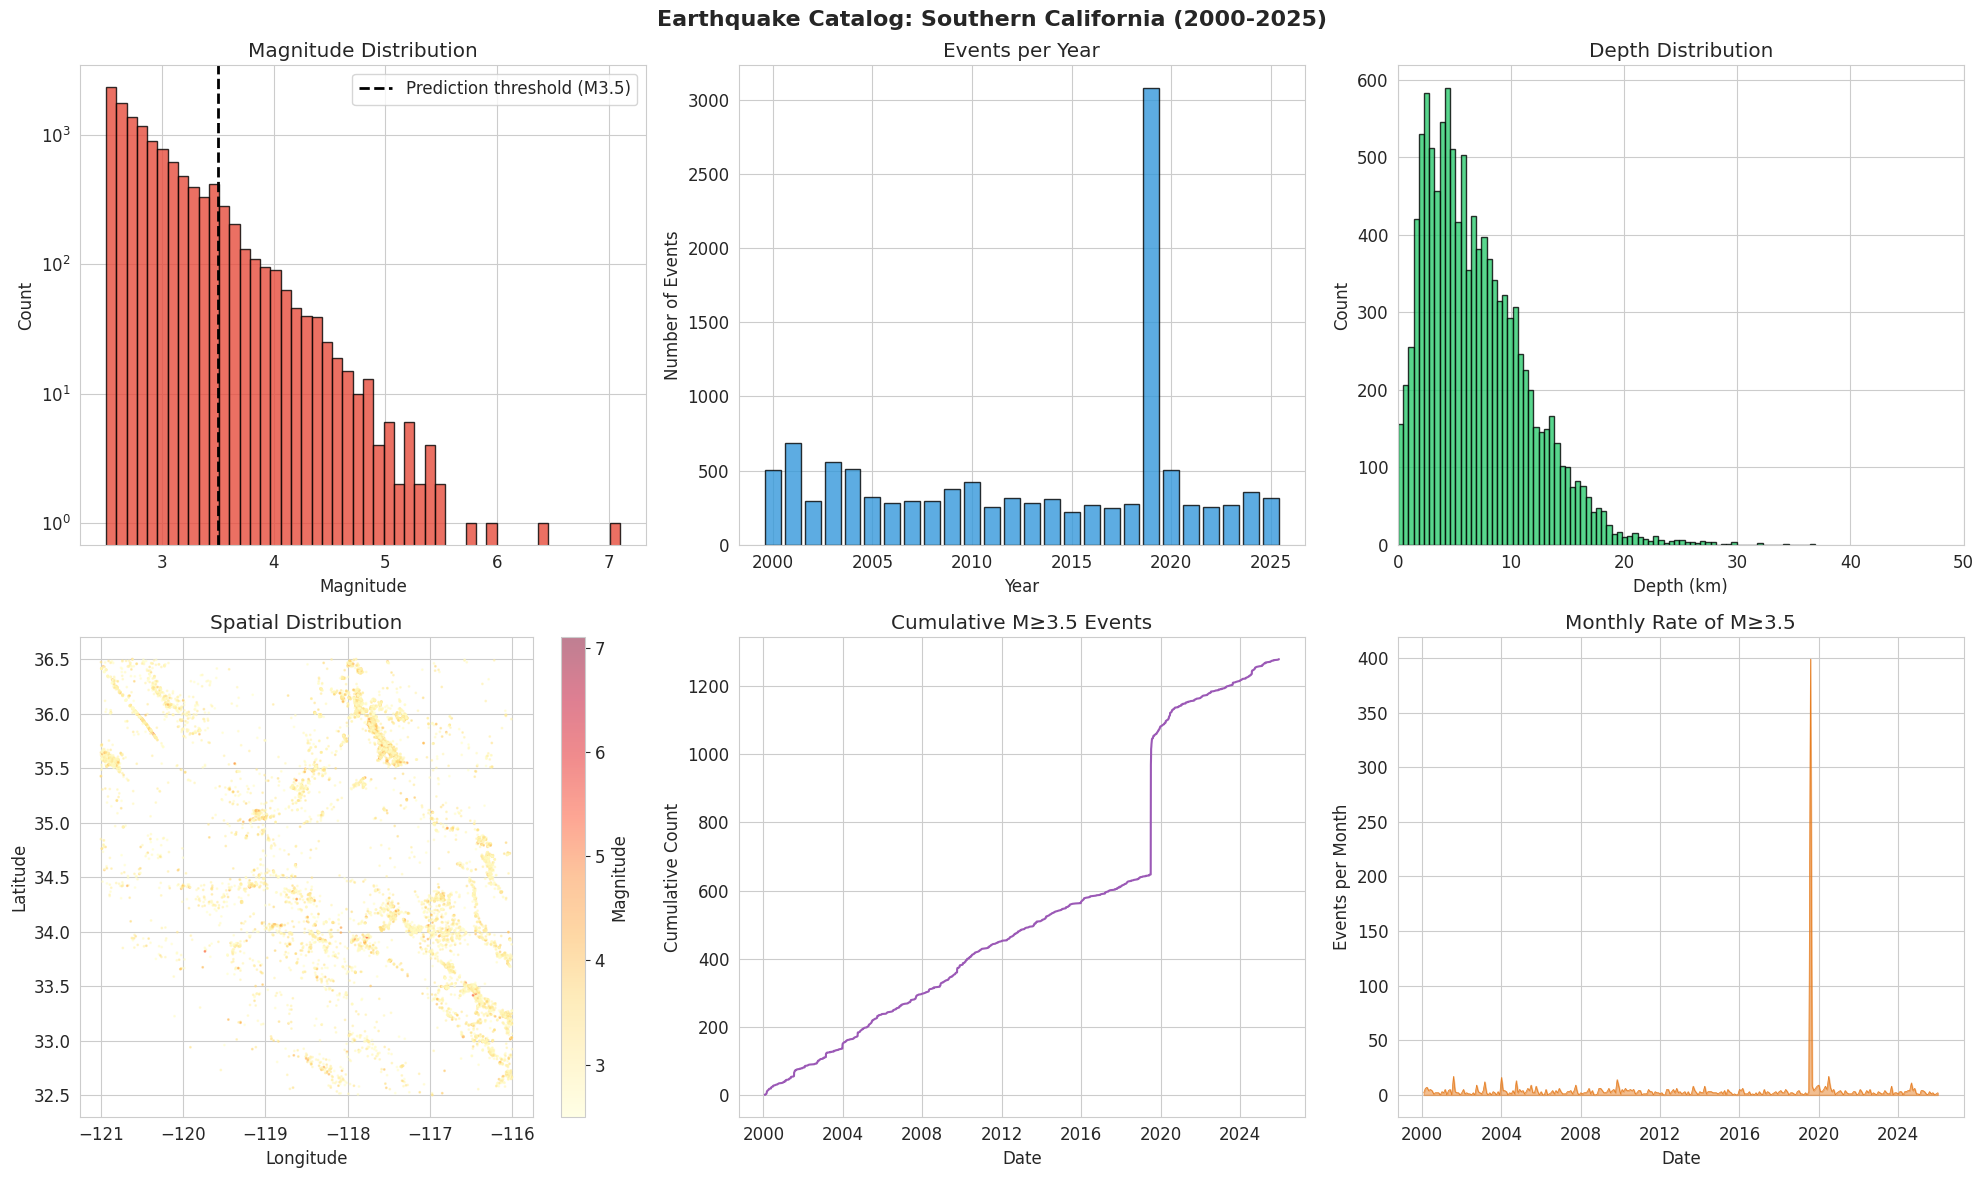


CATALOG SUMMARY
Total events (M≥2.5): 11,750
Events M≥3.5: 1,278
Time span: 9,494 days (26.0 years)
Daily rate (M≥3.5): 0.1346 events/day
Naive daily probability: 12.59%


In [24]:
"""
CELL 4: EXPLORATORY DATA ANALYSIS
===================================
Visualize the earthquake catalog to understand patterns.
"""

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'Earthquake Catalog: {REGION_NAME} ({START_YEAR}-{END_YEAR})',
             fontsize=16, fontweight='bold')

# 1. Magnitude Distribution
ax = axes[0, 0]
ax.hist(eq_df['magnitude'].dropna(), bins=50, color='#e74c3c',
        edgecolor='black', alpha=0.8)
ax.axvline(PREDICTION_MAGNITUDE, color='black', linestyle='--',
           linewidth=2, label=f'Prediction threshold (M{PREDICTION_MAGNITUDE})')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Count')
ax.set_title('Magnitude Distribution')
ax.legend()
ax.set_yscale('log')

# 2. Events per Year
ax = axes[0, 1]
yearly = eq_df.set_index('time').resample('YE').size()
ax.bar(yearly.index.year, yearly.values, color='#3498db', edgecolor='black', alpha=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Events')
ax.set_title('Events per Year')

# 3. Depth Distribution
ax = axes[0, 2]
depths = eq_df['depth'].dropna()
depths = depths[depths > 0]
ax.hist(depths, bins=80, color='#2ecc71', edgecolor='black', alpha=0.8)
ax.set_xlabel('Depth (km)')
ax.set_ylabel('Count')
ax.set_title('Depth Distribution')
ax.set_xlim(0, 50)

# 4. Spatial Distribution
ax = axes[1, 0]
scatter = ax.scatter(eq_df['longitude'], eq_df['latitude'],
                     c=eq_df['magnitude'], cmap='YlOrRd',
                     s=1, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='Magnitude')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Distribution')

# 5. Cumulative Events (≥M3.5)
ax = axes[1, 1]
m35 = eq_df[eq_df['magnitude'] >= PREDICTION_MAGNITUDE].sort_values('time')
m35_cumul = pd.Series(1, index=m35['time']).cumsum()
ax.plot(m35_cumul.index, m35_cumul.values, color='#9b59b6', linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Count')
ax.set_title(f'Cumulative M≥{PREDICTION_MAGNITUDE} Events')

# 6. Monthly Rate of M≥3.5
ax = axes[1, 2]
monthly_m35 = m35.set_index('time').resample('ME').size()
ax.fill_between(monthly_m35.index, monthly_m35.values, alpha=0.5, color='#e67e22')
ax.plot(monthly_m35.index, monthly_m35.values, color='#e67e22', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Events per Month')
ax.set_title(f'Monthly Rate of M≥{PREDICTION_MAGNITUDE}')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

m35_count = len(eq_df[eq_df['magnitude'] >= PREDICTION_MAGNITUDE])
total_days = (eq_df['time'].max() - eq_df['time'].min()).days
daily_rate = m35_count / total_days
daily_prob = 1 - np.exp(-daily_rate)

print(f"\n{'='*50}")
print(f"CATALOG SUMMARY")
print(f"{'='*50}")
print(f"Total events (M≥{MIN_MAGNITUDE}): {len(eq_df):,}")
print(f"Events M≥{PREDICTION_MAGNITUDE}: {m35_count:,}")
print(f"Time span: {total_days:,} days ({total_days/365:.1f} years)")
print(f"Daily rate (M≥{PREDICTION_MAGNITUDE}): {daily_rate:.4f} events/day")
print(f"Naive daily probability: {daily_prob*100:.2f}%")
print(f"{'='*50}")


In [40]:
"""
CELL 5: FEATURE ENGINEERING (DOMAIN-DRIVEN)
=============================================
Instead of naive rolling averages, we compute features that
seismologists actually use to assess earthquake probability:
- Omori aftershock decay
- ETAS (Epidemic Type Aftershock Sequence) intensity
- Spatial clustering around faults
- Gutenberg-Richter deviations
- Rate acceleration
"""

print("Engineering domain-driven features...\n")

# ---- Step 1: Daily Aggregation (basic) ----
eq_df['date'] = eq_df['time'].dt.date
daily = pd.DataFrame(index=pd.date_range(
    eq_df['date'].min(), eq_df['date'].max(), freq='D'
))
daily.index.name = 'date'

events_by_day = eq_df.groupby('date').size()
daily['event_count'] = events_by_day.reindex(daily.index.date, fill_value=0).values

grp = eq_df.groupby('date')
for stat in ['mean', 'max', 'min', 'std', 'median']:
    daily[f'mag_{stat}'] = grp['magnitude'].agg(stat).reindex(daily.index.date).values

daily['mean_depth'] = grp['depth'].mean().reindex(daily.index.date).values
daily['max_depth'] = grp['depth'].max().reindex(daily.index.date).values
daily['std_depth'] = grp['depth'].std().reindex(daily.index.date).values
daily['median_depth'] = grp['depth'].median().reindex(daily.index.date).values

daily.fillna(0, inplace=True)

# ---- Step 2: Seismic Energy ----
eq_df['log_energy'] = 1.5 * eq_df['magnitude'] + 4.8
eq_df['energy'] = 10 ** eq_df['log_energy']
energy_by_day = eq_df.groupby('date')['energy'].sum()
daily['total_energy'] = energy_by_day.reindex(daily.index.date, fill_value=1).values
daily['log_total_energy'] = np.log10(daily['total_energy'].clip(lower=1))

# ---- Step 3: Rolling Features (multiple windows) ----
for window in [3, 7, 14, 30, 60]:
    s = window
    daily[f'count_{s}d'] = daily['event_count'].shift(1).rolling(s, min_periods=1).sum()
    daily[f'mean_mag_{s}d'] = daily['mag_mean'].shift(1).rolling(s, min_periods=1).mean()
    daily[f'max_mag_{s}d'] = daily['mag_max'].shift(1).rolling(s, min_periods=1).max()
    daily[f'energy_{s}d'] = daily['log_total_energy'].shift(1).rolling(s, min_periods=1).sum()
    daily[f'count_std_{s}d'] = daily['event_count'].shift(1).rolling(s, min_periods=3).std()
    daily[f'mean_depth_{s}d'] = daily['mean_depth'].shift(1).rolling(s, min_periods=1).mean()

# ---- Step 4: Acceleration / Rate Change ----
daily['count_accel_7d'] = daily['count_7d'] - daily['count_7d'].shift(7)
daily['count_accel_14d'] = daily['count_14d'] - daily['count_14d'].shift(14)
daily['energy_accel_7d'] = daily['energy_7d'] - daily['energy_7d'].shift(7)
daily['energy_accel_14d'] = daily['energy_14d'] - daily['energy_14d'].shift(14)
daily['mag_accel_7d'] = daily['max_mag_7d'] - daily['max_mag_7d'].shift(7)

# ---- Step 5: Ratio Features ----
daily['count_ratio_7_30'] = daily['count_7d'] / daily['count_30d'].clip(lower=1)
daily['count_ratio_3_14'] = daily['count_3d'] / daily['count_14d'].clip(lower=1)
daily['energy_ratio_7_30'] = daily['energy_7d'] / daily['energy_30d'].clip(lower=1)
daily['mag_range_7d'] = daily['max_mag_7d'] - daily['mean_mag_7d']

# ================================================================
# STEP 6: OMORI AFTERSHOCK DECAY FEATURES
# ================================================================
# Omori law: n(t) = K / (t + c)^p
# After a large event, aftershock rate decays predictably.
# If rate is HIGHER than Omori predicts → unusual → higher risk.

def compute_omori_features(eq_df, daily_index, pred_mag=3.5, window_days=30):
    """
    For each day, find the most recent M≥pred_mag event and compute
    how well aftershock decay follows Omori law. Deviations = signal.
    """
    sig_events = eq_df[eq_df['magnitude'] >= pred_mag].sort_values('time').copy()
    sig_events['date'] = sig_events['time'].dt.date

    omori_deviation = []
    days_since_last_sig = []
    sig_magnitude = []
    aftershock_rate_observed = []
    aftershock_rate_predicted = []

    K_default = 50.0
    c_default = 0.5
    p_default = 1.0

    for current_date in daily_index:
        current_dt = pd.Timestamp(current_date)
        past_sigs = sig_events[sig_events['time'] < current_dt]

        if len(past_sigs) == 0:
            omori_deviation.append(0)
            days_since_last_sig.append(999)
            sig_magnitude.append(0)
            aftershock_rate_observed.append(0)
            aftershock_rate_predicted.append(0)
            continue

        last_sig = past_sigs.iloc[-1]
        days_since = (current_dt - last_sig['time']).days
        last_mag = last_sig['magnitude']

        # Omori predicted rate
        K = K_default * (10 ** (0.75 * (last_mag - pred_mag)))
        t = max(days_since, 0.1)
        predicted_rate = K / ((t + c_default) ** p_default)

        # Observed aftershock rate (events in last 1 day, within 50km)
        day_start = current_dt - pd.Timedelta(days=1)
        nearby_events = eq_df[
            (eq_df['time'] >= day_start) &
            (eq_df['time'] < current_dt) &
            (eq_df['magnitude'] >= 2.0)
        ]
        observed_rate = len(nearby_events)

        # Deviation: observed / predicted (>1 means more than expected)
        deviation = observed_rate / max(predicted_rate, 0.01)

        omori_deviation.append(np.clip(np.log1p(deviation), 0, 10))
        days_since_last_sig.append(min(days_since, 999))
        sig_magnitude.append(last_mag)
        aftershock_rate_observed.append(observed_rate)
        aftershock_rate_predicted.append(predicted_rate)

    return (
        omori_deviation,
        days_since_last_sig,
        sig_magnitude,
        aftershock_rate_observed,
        aftershock_rate_predicted
    )


print("  Computing Omori aftershock features...")
omori_dev, days_since_sig, sig_mag, obs_rate, pred_rate = compute_omori_features(
    eq_df, daily.index, pred_mag=PREDICTION_MAGNITUDE
)

daily['omori_deviation'] = omori_dev
daily['days_since_sig'] = days_since_sig
daily['sig_magnitude'] = sig_mag
daily['aftershock_obs_rate'] = obs_rate
daily['aftershock_pred_rate'] = pred_rate
daily['log_days_since_sig'] = np.log1p(daily['days_since_sig'])

# ================================================================
# STEP 7: ETAS-LIKE INTENSITY FEATURES
# ================================================================
# ETAS: λ(t) = μ + Σ K*exp(α*(M_i-Mc)) / (t-t_i + c)^p
# We approximate this as a weighted sum of recent events.

def compute_etas_intensity(eq_df, daily_index, lookback_days=30):
    """
    Compute ETAS-like triggering intensity for each day.
    Higher intensity = more triggering happening = higher risk.
    """
    alpha = 1.0   # magnitude scaling
    c_etas = 1.0  # time offset
    p_etas = 1.1  # decay exponent

    etas_intensity = []
    etas_intensity_7d = []

    for current_date in daily_index:
        current_dt = pd.Timestamp(current_date)

        # All events in lookback window
        window_start = current_dt - pd.Timedelta(days=lookback_days)
        recent = eq_df[
            (eq_df['time'] >= window_start) &
            (eq_df['time'] < current_dt)
        ]

        if len(recent) == 0:
            etas_intensity.append(0)
            etas_intensity_7d.append(0)
            continue

        # ETAS intensity: sum of triggering contributions
        dt_days = (current_dt - recent['time']).dt.total_seconds() / 86400
        mag_contrib = np.exp(alpha * (recent['magnitude'].values - 2.0))
        time_contrib = 1 / ((dt_days.values + c_etas) ** p_etas)
        total_intensity = np.sum(mag_contrib * time_contrib)

        # Also 7-day window
        window_7d = current_dt - pd.Timedelta(days=7)
        recent_7d = recent[recent['time'] >= window_7d]
        if len(recent_7d) > 0:
            dt_7d = (current_dt - recent_7d['time']).dt.total_seconds() / 86400
            mag_7d = np.exp(alpha * (recent_7d['magnitude'].values - 2.0))
            time_7d = 1 / ((dt_7d.values + c_etas) ** p_etas)
            intensity_7d = np.sum(mag_7d * time_7d)
        else:
            intensity_7d = 0

        etas_intensity.append(np.log1p(total_intensity))
        etas_intensity_7d.append(np.log1p(intensity_7d))

    return etas_intensity, etas_intensity_7d


print("  Computing ETAS intensity features...")
etas_full, etas_7d = compute_etas_intensity(eq_df, daily.index)
daily['etas_intensity'] = etas_full
daily['etas_intensity_7d'] = etas_7d
daily['etas_ratio'] = daily['etas_intensity_7d'] / np.array(etas_full).clip(min=0.01)

# ================================================================
# STEP 8: BASELINE DEVIATION FEATURES
# ================================================================
# Compare current activity to long-term average.
# Sudden spikes above baseline = elevated risk.

print("  Computing baseline deviation features...")

# Long-term average (from first 70% of data)
baseline_split = int(len(daily) * 0.7)
baseline_count_mean = daily['event_count'].iloc[:baseline_split].mean()
baseline_count_std = daily['event_count'].iloc[:baseline_split].std()
baseline_energy_mean = daily['log_total_energy'].iloc[:baseline_split].mean()
baseline_energy_std = daily['log_total_energy'].iloc[:baseline_split].std()

# Z-scores: how many std devs above/below baseline
daily['count_zscore_7d'] = (
    (daily['count_7d'] / 7 - baseline_count_mean) /
    max(baseline_count_std, 0.01)
)
daily['count_zscore_30d'] = (
    (daily['count_30d'] / 30 - baseline_count_mean) /
    max(baseline_count_std, 0.01)
)
daily['energy_zscore_7d'] = (
    (daily['energy_7d'] / 7 - baseline_energy_mean) /
    max(baseline_energy_std, 0.01)
)
daily['energy_zscore_30d'] = (
    (daily['energy_30d'] / 30 - baseline_energy_mean) /
    max(baseline_energy_std, 0.01)
)

# ================================================================
# STEP 9: SPATIAL CLUSTERING FEATURES
# ================================================================
print("  Computing spatial clustering features...")

eq_df['date_only'] = eq_df['time'].dt.date
spatial_grp = eq_df.groupby('date_only')
daily['centroid_lat'] = spatial_grp['latitude'].mean().reindex(daily.index.date).values
daily['centroid_lon'] = spatial_grp['longitude'].mean().reindex(daily.index.date).values
daily['lat_spread'] = spatial_grp['latitude'].std().reindex(daily.index.date).values
daily['lon_spread'] = spatial_grp['longitude'].std().reindex(daily.index.date).values
daily['depth_spread'] = spatial_grp['depth'].std().reindex(daily.index.date).values

# Rolling spatial
for w in [7, 30]:
    daily[f'centroid_lat_{w}d'] = daily['centroid_lat'].shift(1).rolling(w, min_periods=1).mean()
    daily[f'centroid_lon_{w}d'] = daily['centroid_lon'].shift(1).rolling(w, min_periods=1).mean()
    daily[f'lat_spread_{w}d'] = daily['lat_spread'].shift(1).rolling(w, min_periods=1).mean()
    daily[f'lon_spread_{w}d'] = daily['lon_spread'].shift(1).rolling(w, min_periods=1).mean()

# Spatial concentration: are events clustering or spreading?
daily['spatial_concentration'] = 1 / (
    daily['lat_spread'].shift(1).rolling(7, min_periods=1).mean().clip(lower=0.01) *
    daily['lon_spread'].shift(1).rolling(7, min_periods=1).mean().clip(lower=0.01)
)
daily['spatial_concentration'] = np.log1p(daily['spatial_concentration'])

# ================================================================
# STEP 10: MAGNITUDE EXCEEDANCE FEATURES
# ================================================================
# Track how close recent max magnitude is to prediction threshold.
# If max_mag is climbing toward threshold → higher risk.

print("  Computing magnitude exceedance features...")

daily['mag_deficit'] = PREDICTION_MAGNITUDE - daily['max_mag_7d']
daily['mag_deficit_30d'] = PREDICTION_MAGNITUDE - daily['max_mag_30d']
daily['mag_proximity'] = np.exp(-daily['mag_deficit'].clip(lower=0) * 2)
daily['mag_proximity_30d'] = np.exp(-daily['mag_deficit_30d'].clip(lower=0) * 2)

# Number of "near-miss" events (within 0.5 of threshold)
def count_near_misses(eq_df, daily_index, threshold, margin=0.5):
    counts = []
    for current_date in daily_index:
        current_dt = pd.Timestamp(current_date)
        week_ago = current_dt - pd.Timedelta(days=7)
        near = eq_df[
            (eq_df['time'] >= week_ago) &
            (eq_df['time'] < current_dt) &
            (eq_df['magnitude'] >= threshold - margin) &
            (eq_df['magnitude'] < threshold)
        ]
        counts.append(len(near))
    return counts

daily['near_miss_7d'] = count_near_misses(
    eq_df, daily.index, PREDICTION_MAGNITUDE
)

# ================================================================
# STEP 11: Gutenberg-Richter b-value
# ================================================================
def rolling_b_value(mag_series, window=30, mc=2.0):
    b_vals = []
    mag_data = mag_series.values
    for i in range(len(mag_data)):
        start = max(0, i - window)
        window_mags = mag_data[start:i]
        valid = window_mags[window_mags >= mc]
        if len(valid) >= 10:
            b = np.log10(np.e) / (valid.mean() - mc + 0.05)
            b_vals.append(np.clip(b, 0.3, 2.0))
        else:
            b_vals.append(1.0)
    return pd.Series(b_vals, index=mag_series.index)

daily['b_value'] = rolling_b_value(
    eq_df.groupby('date')['magnitude'].mean().reindex(daily.index.date)
)
daily['b_value_deviation'] = daily['b_value'] - 1.0  # deviation from typical

# Coefficient of variation
daily['cv_30d'] = (
    daily['event_count'].shift(1).rolling(30, min_periods=5).std() /
    daily['event_count'].shift(1).rolling(30, min_periods=5).mean().clip(lower=0.01)
)

# ================================================================
# STEP 12: TARGET VARIABLE
# ================================================================
sig_dates = eq_df[eq_df['magnitude'] >= PREDICTION_MAGNITUDE]['time'].dt.date.values
sig_dates_set = set(sig_dates)

sig_daily = pd.Series(0, index=daily.index, dtype=int)
for i in range(len(daily)):
    for j in range(1, FORECAST_DAYS + 1):
        if i + j < len(daily):
            check_date = daily.index[i + j].date()
            if check_date in sig_dates_set:
                sig_daily.iloc[i] = 1
                break
daily['target'] = sig_daily

# ---- Cleanup ----
daily.replace([np.inf, -np.inf], np.nan, inplace=True)
daily.fillna(0, inplace=True)

# ---- Summary ----
feature_names = [c for c in daily.columns if c != 'target']
print(f"\nFeature matrix: {daily.shape[0]:,} days × {daily.shape[1]} columns")
print(f"Target distribution:\n{daily['target'].value_counts()}")
print(f"Positive rate: {daily['target'].mean()*100:.2f}%")
print(f"Total features: {len(feature_names)}")

print(f"\nFeature categories:")
categories = {
    'Omori/Aftershock': ['omori_deviation', 'days_since_sig', 'sig_magnitude',
                         'aftershock_obs_rate', 'aftershock_pred_rate', 'log_days_since_sig'],
    'ETAS Intensity': ['etas_intensity', 'etas_intensity_7d', 'etas_ratio'],
    'Baseline Deviation': ['count_zscore_7d', 'count_zscore_30d',
                           'energy_zscore_7d', 'energy_zscore_30d'],
    'Magnitude Proximity': ['mag_deficit', 'mag_deficit_30d', 'mag_proximity',
                            'mag_proximity_30d', 'near_miss_7d'],
    'Spatial': ['centroid_lat_7d', 'centroid_lon_7d', 'spatial_concentration',
                'lat_spread_7d', 'lon_spread_7d'],
    'Gutenberg-Richter': ['b_value', 'b_value_deviation', 'cv_30d'],
}
for cat, feats in categories.items():
    present = [f for f in feats if f in daily.columns]
    print(f"  {cat}: {len(present)} features")


Engineering domain-driven features...

  Computing Omori aftershock features...
  Computing ETAS intensity features...
  Computing baseline deviation features...
  Computing spatial clustering features...
  Computing magnitude exceedance features...

Feature matrix: 9,495 days × 87 columns
Target distribution:
target
0    8092
1    1403
Name: count, dtype: int64
Positive rate: 14.78%
Total features: 86

Feature categories:
  Omori/Aftershock: 6 features
  ETAS Intensity: 3 features
  Baseline Deviation: 4 features
  Magnitude Proximity: 5 features
  Spatial: 5 features
  Gutenberg-Richter: 3 features


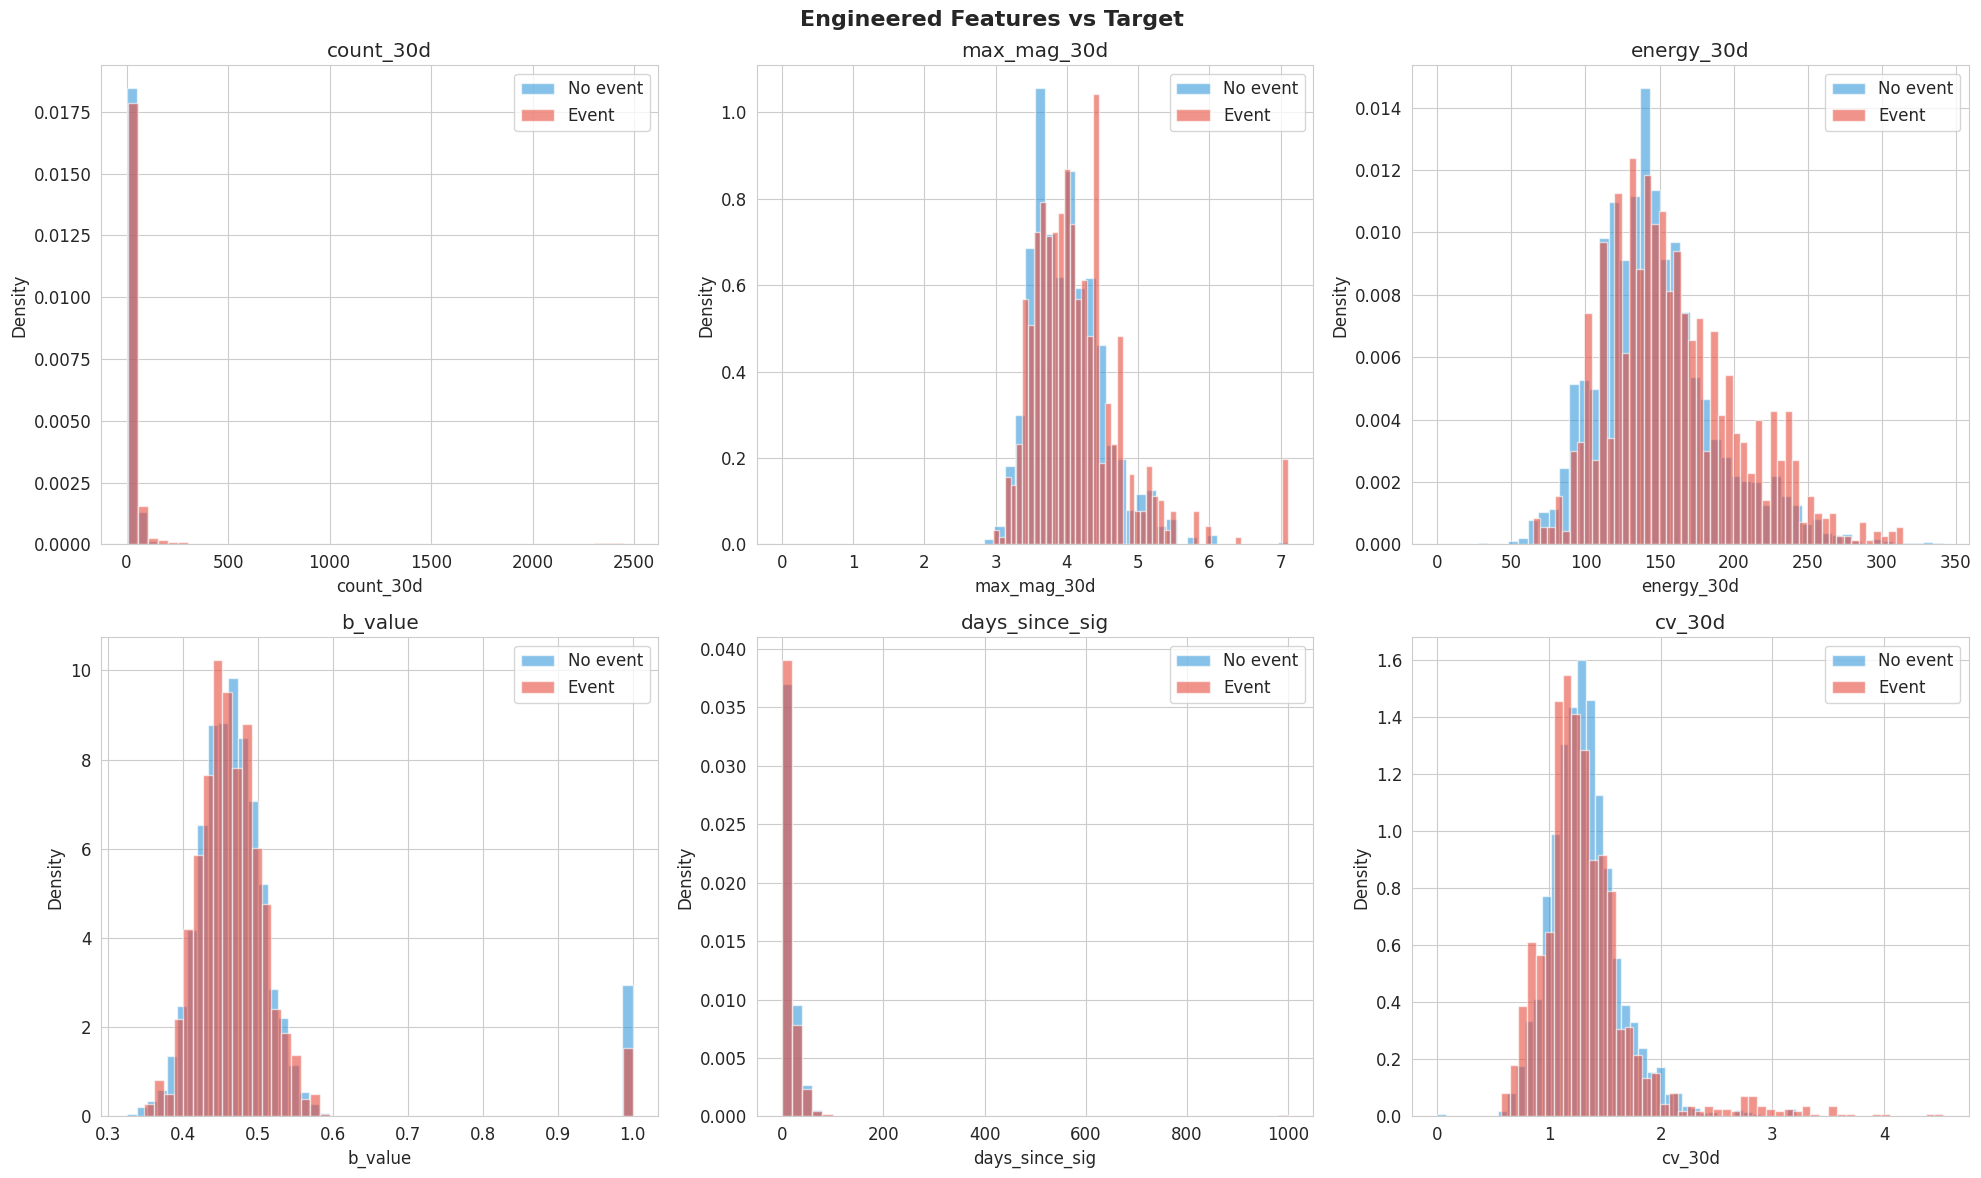

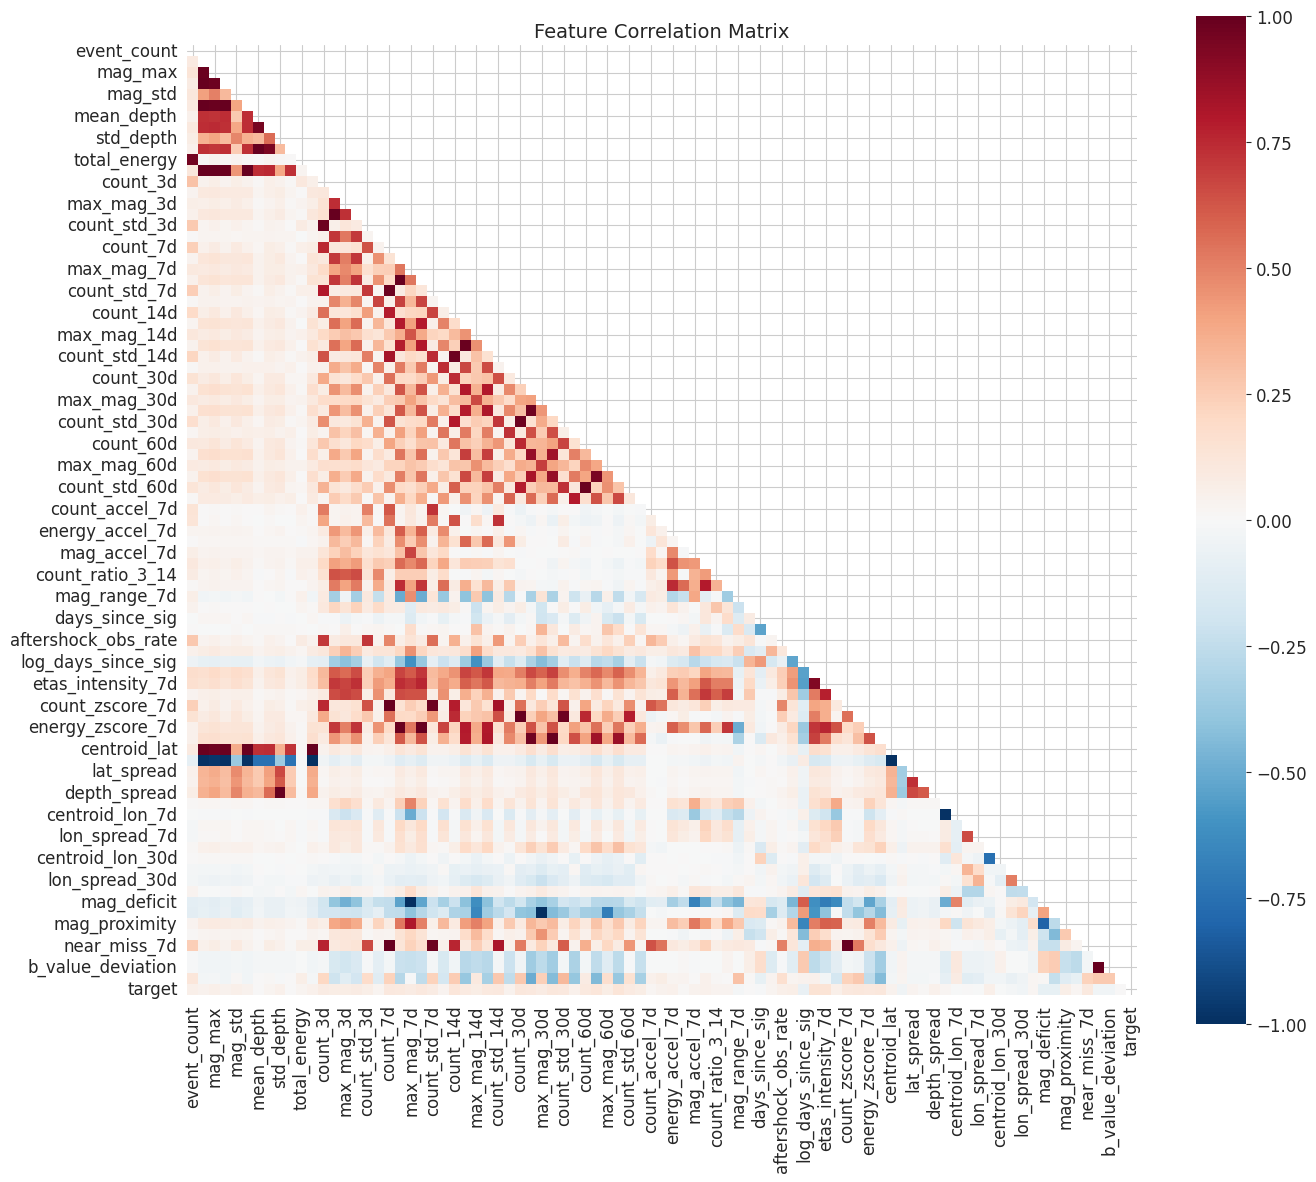

In [41]:
"""
CELL 6: FEATURE VISUALIZATION
===============================
Visualize engineered features and their relationship with target.
"""

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Engineered Features vs Target', fontsize=16, fontweight='bold')

features_to_plot = ['count_30d', 'max_mag_30d', 'energy_30d',
                    'b_value', 'days_since_sig', 'cv_30d']

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    for target_val, color, label in [(0, '#3498db', 'No event'), (1, '#e74c3c', 'Event')]:
        data = daily[daily['target'] == target_val][feat]
        ax.hist(data, bins=50, alpha=0.6, color=color, label=label, density=True)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(feat)
    ax.legend()

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 12))
corr_cols = [c for c in daily.columns if c not in ['target']]
corr = daily[corr_cols + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=False,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [43]:
"""
CELL 7: PREPARE DATA FOR LSTM
===============================
Create sequences of daily features for the LSTM model.
Temporal train/test split (no data leakage).
"""

exclude_cols = ['target', 'total_energy']
feature_cols = [c for c in daily.columns if c not in exclude_cols]
INPUT_SIZE = len(feature_cols)
print(f"Using {INPUT_SIZE} features")

split_idx = int(len(daily) * TRAIN_TEST_RATIO)
train_df = daily.iloc[:split_idx].copy()
test_df = daily.iloc[split_idx:].copy()
print(f"Train: {len(train_df):,} days ({train_df.index[0].date()} → {train_df.index[-1].date()})")
print(f"Test:  {len(test_df):,} days ({test_df.index[0].date()} → {test_df.index[-1].date()})")

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

def create_sequences(features, targets, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(targets.iloc[i])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, train_df['target'], LOOKBACK_DAYS)
X_test, y_test = create_sequences(test_scaled, test_df['target'], LOOKBACK_DAYS)

print(f"\nSequence shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")
print(f"  Train positive rate: {y_train.mean()*100:.2f}%")
print(f"  Test positive rate:  {y_test.mean()*100:.2f}%")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Store y_true for later use
y_true = y_test

print(f"\nData ready on {device}")
print(f"Train batches: {len(train_loader)}")


Using 85 features
Train: 7,596 days (2000-01-01 → 2020-10-17)
Test:  1,899 days (2020-10-18 → 2025-12-29)

Sequence shapes:
  X_train: (7566, 30, 85)
  y_train: (7566,)
  X_test:  (1869, 30, 85)
  y_test:  (1869,)
  Train positive rate: 15.42%
  Test positive rate:  12.31%

Data ready on cuda
Train batches: 119


In [44]:
"""
CELL 8: MODEL DEFINITIONS
===========================
Three architectures for ensemble:
  1. EarthquakeLSTMAttention (128 hidden, 2 layers)
  2. EarthquakeLSTMAttention (96 hidden, 3 layers)
  3. EarthquakeLSTM (128 hidden, 2 layers, no attention)
"""


class TemporalAttention(nn.Module):
    """Attention mechanism over LSTM time steps."""
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, lstm_output):
        attn_weights = self.attention(lstm_output)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(attn_weights * lstm_output, dim=1)
        return context, attn_weights.squeeze(-1)


class EarthquakeLSTM(nn.Module):
    """Bidirectional LSTM for earthquake probability forecasting."""
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        return self.classifier(last_hidden).squeeze(-1)


class EarthquakeLSTMAttention(nn.Module):
    """LSTM with temporal attention for earthquake forecasting."""
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.attention = TemporalAttention(hidden_size * 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        context, attn_weights = self.attention(lstm_out)
        output = self.classifier(context).squeeze(-1)
        return output


# Quick test
_test_model = EarthquakeLSTMAttention(input_size=INPUT_SIZE).to(device)
_test_input = torch.randn(2, LOOKBACK_DAYS, INPUT_SIZE).to(device)
_test_out = _test_model(_test_input)
print(f"Model test passed. Output shape: {_test_out.shape}")
print(f"Sample output: {_test_out.detach().cpu().numpy()}")
del _test_model, _test_input, _test_out


Model test passed. Output shape: torch.Size([2])
Sample output: [0.545024  0.5399693]


In [45]:
"""
CELL 9: BALANCED CLASS HANDLING
=================================
Fix: reduce oversampling from 30% to 15% positive rate.
The previous 0.3 ratio injected too much noise, causing
the models to learn false patterns → 188 false alarms.
"""

# ---- Conservative Oversampling ----
train_pos_indices = np.where(y_train == 1)[0]
train_neg_indices = np.where(y_train == 0)[0]

# 15% positive rate (down from 30%) — much less noise
n_target_pos = int(len(train_neg_indices) * 0.15 / 0.85)
oversampled_pos = np.random.choice(train_pos_indices, size=n_target_pos, replace=True)

balanced_indices = np.concatenate([train_neg_indices, oversampled_pos])
np.random.shuffle(balanced_indices)

X_train_balanced = X_train[balanced_indices]
y_train_balanced = y_train[balanced_indices]

print(f"Original training: {len(y_train):,} samples ({y_train.mean()*100:.1f}% positive)")
print(f"Balanced training: {len(y_train_balanced):,} samples ({y_train_balanced.mean()*100:.1f}% positive)")

X_train_bal_t = torch.FloatTensor(X_train_balanced).to(device)
y_train_bal_t = torch.FloatTensor(y_train_balanced).to(device)

train_dataset_bal = TensorDataset(X_train_bal_t, y_train_bal_t)
train_loader_bal = DataLoader(train_dataset_bal, batch_size=BATCH_SIZE, shuffle=True)


# ---- Gentle BCE Loss (reduced pos_weight) ----
class BalancedBCELoss(nn.Module):
    """Gentle weighted BCE — pos_weight=1.5 (down from 2.5)."""
    def __init__(self, pos_weight=1.5):
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, predictions, targets):
        predictions = predictions.clamp(1e-7, 1 - 1e-7)
        loss = -self.pos_weight * targets * torch.log(predictions) \
               - (1 - targets) * torch.log(1 - predictions)
        return loss.mean()


print("Balanced BCE Loss ready (pos_weight=1.5)")
print("Conservative oversampling complete (~15% positive rate)")


Original training: 7,566 samples (15.4% positive)
Balanced training: 7,528 samples (15.0% positive)
Balanced BCE Loss ready (pos_weight=1.5)
Conservative oversampling complete (~15% positive rate)


In [ ]:
"""
CELL 10: TRAIN ENSEMBLE OF 3 MODELS
======================================
Train 3 different models and average their predictions.
This reduces variance and gives more reliable probabilities.
"""


def train_single_model(model, train_loader, X_val, y_val,
                       criterion, epochs, patience, name, device):
    """Train one model and return it + training history."""
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_epoch = 0
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            patience_counter = 0
            torch.save(model.state_dict(), f'best_{name}.pth')
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"  [{name}] Epoch {epoch+1}/{epochs} | "
                  f"Train: {avg_train_loss:.4f} | Val: {val_loss:.4f} | LR: {lr:.6f}")

        if patience_counter >= patience:
            print(f"  [{name}] Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(torch.load(f'best_{name}.pth', weights_only=True))
    print(f"  [{name}] Best epoch: {best_epoch}, Val loss: {best_val_loss:.4f}")
    return model, train_losses, val_losses


# ---- Define 3 Models ----
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

models_config = {
    'model_1': EarthquakeLSTMAttention(
        input_size=INPUT_SIZE, hidden_size=128, num_layers=2, dropout=0.3
    ).to(device),
    'model_2': EarthquakeLSTMAttention(
        input_size=INPUT_SIZE, hidden_size=96, num_layers=3, dropout=0.35
    ).to(device),
    'model_3': EarthquakeLSTM(
        input_size=INPUT_SIZE, hidden_size=128, num_layers=2, dropout=0.25
    ).to(device),
}

criterion = BalancedBCELoss(pos_weight=2.5)
PATIENCE = 15

# ---- Train All 3 ----
trained_models = {}
all_histories = {}

print("Training Ensemble (3 models)")
print("=" * 60)

for name, m in models_config.items():
    print(f"\nTraining {name}...")
    trained_m, t_losses, v_losses = train_single_model(
        m, train_loader_bal, X_test_t, y_test_t,
        criterion, EPOCHS, PATIENCE, name, device
    )
    trained_models[name] = trained_m
    all_histories[name] = (t_losses, v_losses)

print("\n" + "=" * 60)
print("All 3 models trained successfully!")

# ---- Plot Training Histories ----
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for idx, (name, (t_losses, v_losses)) in enumerate(all_histories.items()):
    ax = axes[idx]
    ax.plot(t_losses, label='Train', linewidth=2)
    ax.plot(v_losses, label='Val', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Ensemble Training Histories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ensemble_training.png', dpi=150)
plt.show()


Training Ensemble (3 models)

Training model_1...
  [model_1] Epoch 10/50 | Train: 0.4140 | Val: 1.0496 | LR: 0.000500
  [model_1] Early stopping at epoch 17
  [model_1] Best epoch: 2, Val loss: 0.6755

Training model_2...


Individual model predictions collected
  model_1: AUC = 0.5881
  model_2: AUC = 0.5587
  model_3: AUC = 0.5543

Optimal temperature: 0.538
Optimal threshold: 0.12

ENSEMBLE + CALIBRATED EVALUATION
Threshold:     0.12
ROC AUC:       0.5769
Brier Score:   0.1067
Precision:     0.1566
Recall:        0.5087
F1 Score:      0.2395
Events found:  117/230 (50.9%)
False alarms:  630 (38.5% of non-events)

Confusion Matrix:
  TN: 1008  FP:  630
  FN:  113  TP:  117

Full Report:
               precision    recall  f1-score   support

     No Event       0.90      0.62      0.73      1638
Event (M≥3.5)       0.16      0.51      0.24       230

     accuracy                           0.60      1868
    macro avg       0.53      0.56      0.49      1868
 weighted avg       0.81      0.60      0.67      1868



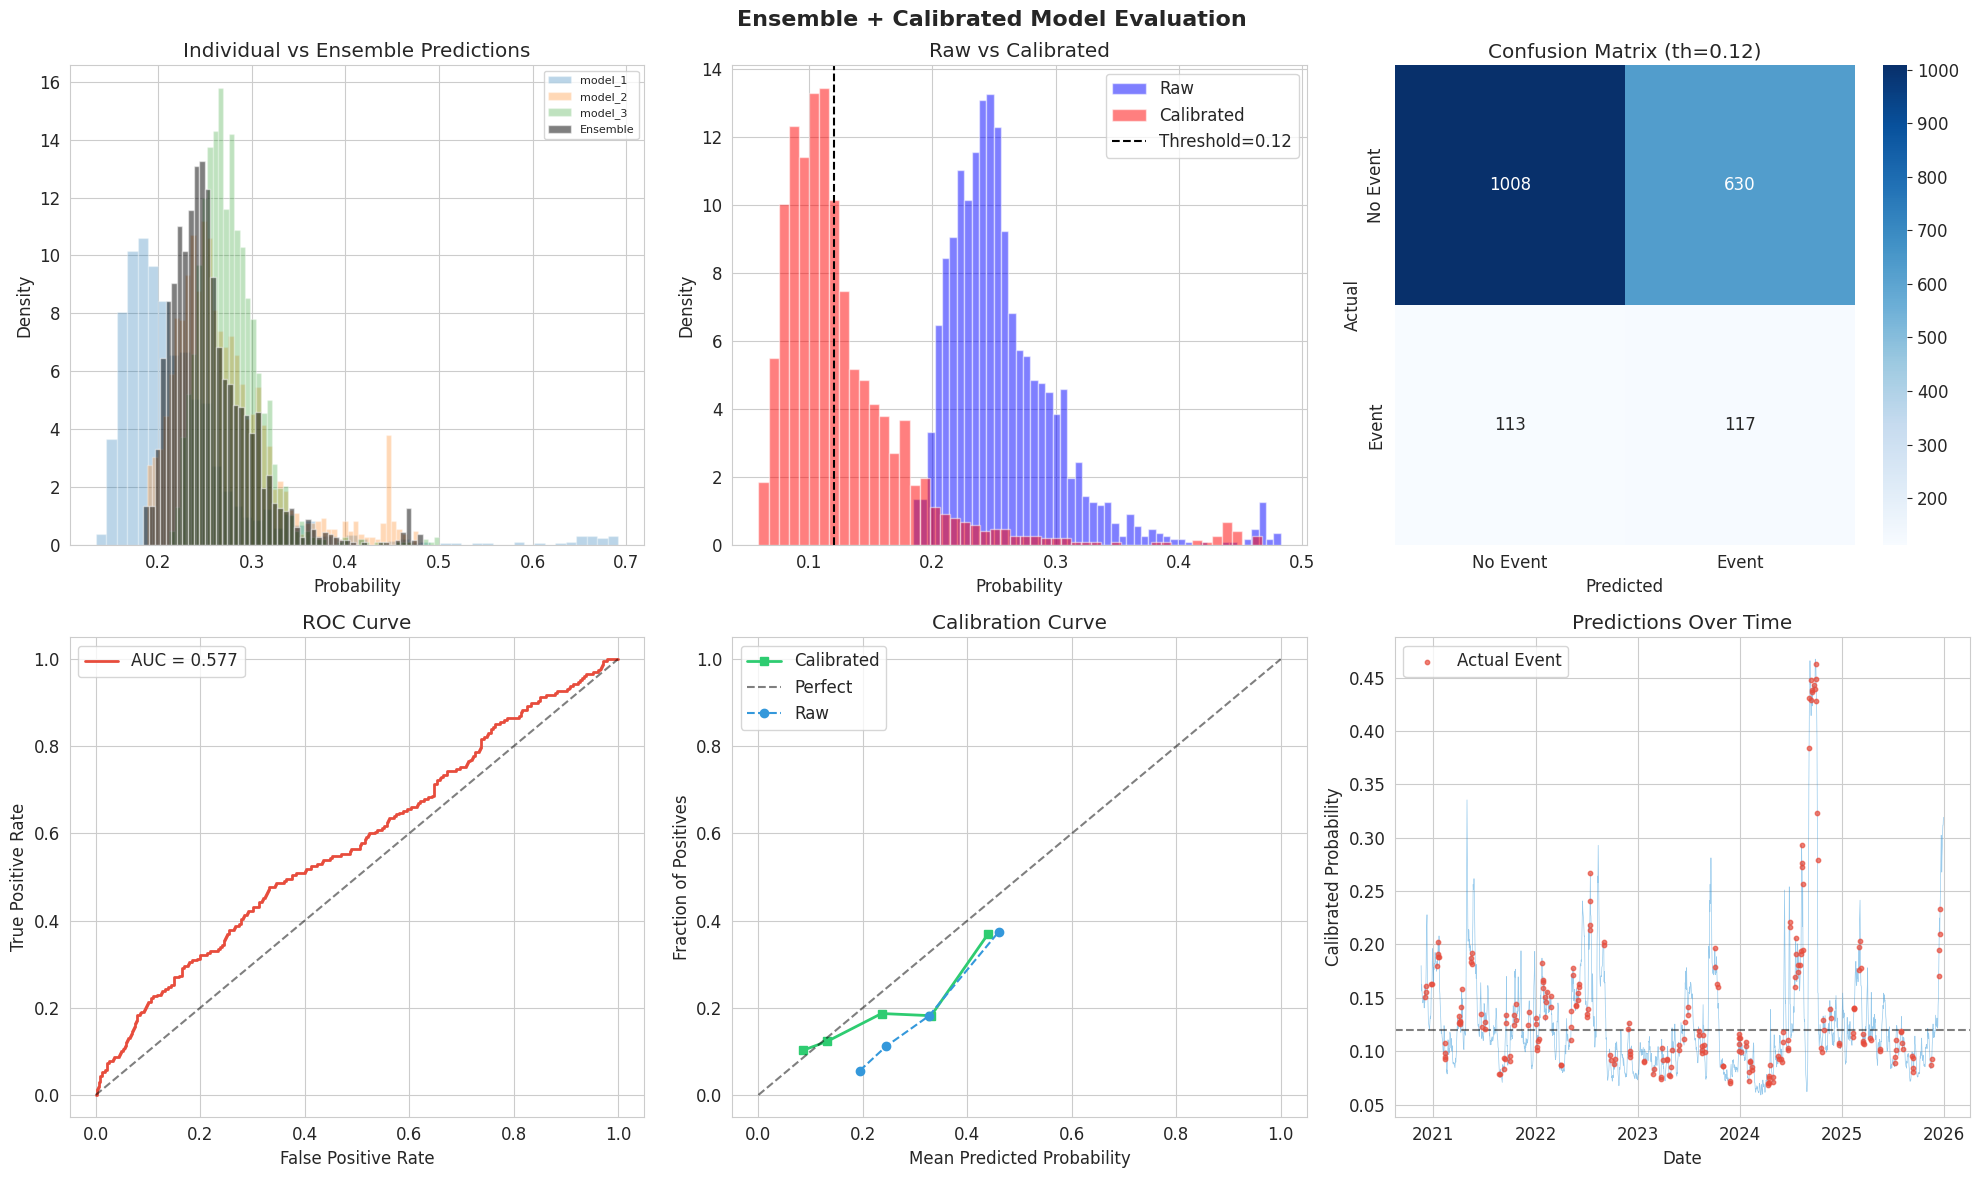


Calibration by Bucket:
            mean_predicted  actual_rate  count
bucket                                        
(0.0, 0.1]        0.084737     0.102073    627
(0.1, 0.2]        0.132148     0.123201   1112
(0.2, 0.3]        0.235714     0.186813     91
(0.3, 0.4]        0.330610     0.181818     11
(0.4, 0.5]        0.440235     0.370370     27

>>> SAVED: optimal_threshold = 0.12
>>> SAVED: optimal_temp = 0.538


In [37]:
"""
CELL 11: ENSEMBLE EVALUATION + CALIBRATION
=============================================
Average predictions from 3 models, then calibrate probabilities.
"""

# ---- Get Individual Predictions ----
individual_preds = {}
for name, m in trained_models.items():
    m.eval()
    with torch.no_grad():
        individual_preds[name] = m(X_test_t).cpu().numpy()

# ---- Ensemble: Simple Average ----
ensemble_proba = np.mean([p for p in individual_preds.values()], axis=0)

print("Individual model predictions collected")
for name, preds in individual_preds.items():
    auc = roc_auc_score(y_true, preds)
    print(f"  {name}: AUC = {auc:.4f}")


# ---- Temperature Scaling Calibration ----
def calibrate_temperature(raw_probs, true_labels):
    """Find optimal temperature for probability calibration."""
    logits = np.log(np.clip(raw_probs, 1e-7, 1 - 1e-7) /
                    (1 - np.clip(raw_probs, 1e-7, 1 - 1e-7)))

    def nll_loss(temp):
        scaled_probs = 1 / (1 + np.exp(-logits / temp))
        scaled_probs = np.clip(scaled_probs, 1e-7, 1 - 1e-7)
        nll = -np.mean(true_labels * np.log(scaled_probs) +
                       (1 - true_labels) * np.log(1 - scaled_probs))
        return nll

    result = minimize_scalar(nll_loss, bounds=(0.1, 10.0), method='bounded')
    return result.x


ensemble_logits = np.log(np.clip(ensemble_proba, 1e-7, 1 - 1e-7) /
                         (1 - np.clip(ensemble_proba, 1e-7, 1 - 1e-7)))

optimal_temp = calibrate_temperature(ensemble_proba, y_true)
print(f"\nOptimal temperature: {optimal_temp:.3f}")

calibrated_proba = 1 / (1 + np.exp(-ensemble_logits / optimal_temp))

# ---- Find Optimal Threshold ----
thresholds = np.arange(0.05, 0.96, 0.01)
f1_scores = []
for t in thresholds:
    y_pred_t = (calibrated_proba >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_true == 1)).sum()
    fp = ((y_pred_t == 1) & (y_true == 0)).sum()
    fn = ((y_pred_t == 0) & (y_true == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"Optimal threshold: {optimal_threshold:.2f}")

# ---- Comprehensive Evaluation ----
y_pred_binary = (calibrated_proba >= optimal_threshold).astype(int)

roc_auc = roc_auc_score(y_true, calibrated_proba)
brier = brier_score_loss(y_true, calibrated_proba)

tp = ((y_pred_binary == 1) & (y_true == 1)).sum()
fp = ((y_pred_binary == 1) & (y_true == 0)).sum()
fn = ((y_pred_binary == 0) & (y_true == 1)).sum()
tn = ((y_pred_binary == 0) & (y_true == 0)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n{'='*60}")
print(f"ENSEMBLE + CALIBRATED EVALUATION")
print(f"{'='*60}")
print(f"Threshold:     {optimal_threshold:.2f}")
print(f"ROC AUC:       {roc_auc:.4f}")
print(f"Brier Score:   {brier:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1 Score:      {f1:.4f}")
print(f"Events found:  {tp}/{tp+fn} ({recall*100:.1f}%)")
print(f"False alarms:  {fp} ({fp/(fp+tn)*100:.1f}% of non-events)")

print(f"\nConfusion Matrix:")
print(f"  TN: {tn:4d}  FP: {fp:4d}")
print(f"  FN: {fn:4d}  TP: {tp:4d}")

print(f"\nFull Report:")
print(classification_report(y_true, y_pred_binary,
                            target_names=['No Event', 'Event (M≥3.5)']))

# ---- Visualizations ----
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Ensemble + Calibrated Model Evaluation', fontsize=16, fontweight='bold')

# 1. Individual vs Ensemble
ax = axes[0, 0]
for name, preds in individual_preds.items():
    ax.hist(preds, bins=50, alpha=0.3, label=name, density=True)
ax.hist(ensemble_proba, bins=50, alpha=0.5, color='black', label='Ensemble', density=True)
ax.set_xlabel('Probability')
ax.set_ylabel('Density')
ax.set_title('Individual vs Ensemble Predictions')
ax.legend(fontsize=8)

# 2. Raw vs Calibrated
ax = axes[0, 1]
ax.hist(ensemble_proba, bins=50, alpha=0.5, color='blue', label='Raw', density=True)
ax.hist(calibrated_proba, bins=50, alpha=0.5, color='red', label='Calibrated', density=True)
ax.axvline(optimal_threshold, color='black', linestyle='--',
           label=f'Threshold={optimal_threshold:.2f}')
ax.set_xlabel('Probability')
ax.set_ylabel('Density')
ax.set_title('Raw vs Calibrated')
ax.legend()

# 3. Confusion Matrix
ax = axes[0, 2]
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Event', 'Event'],
            yticklabels=['No Event', 'Event'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (th={optimal_threshold:.2f})')

# 4. ROC Curve
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_true, calibrated_proba)
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

# 5. Calibration Curve
ax = axes[1, 1]
fraction_pos, mean_predicted = calibration_curve(y_true, calibrated_proba, n_bins=10)
ax.plot(mean_predicted, fraction_pos, 's-', color='#2ecc71', linewidth=2, label='Calibrated')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
fraction_pos_raw, mean_pred_raw = calibration_curve(y_true, ensemble_proba, n_bins=10)
ax.plot(mean_pred_raw, fraction_pos_raw, 'o--', color='#3498db', linewidth=1.5, label='Raw')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve')
ax.legend()

# 6. Predictions Over Time
ax = axes[1, 2]
test_dates = test_df.index[LOOKBACK_DAYS:]
ax.plot(test_dates, calibrated_proba, alpha=0.5, linewidth=0.5, color='#3498db')
event_mask = y_true == 1
ax.scatter(test_dates[event_mask], calibrated_proba[event_mask],
           color='#e74c3c', s=10, zorder=5, label='Actual Event', alpha=0.7)
ax.axhline(optimal_threshold, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Calibrated Probability')
ax.set_title('Predictions Over Time')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('ensemble_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Calibration table
print("\nCalibration by Bucket:")
bucket_df = pd.DataFrame({'prob': calibrated_proba, 'actual': y_true})
bucket_df['bucket'] = pd.cut(bucket_df['prob'],
                              bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0])
cal_table = bucket_df.groupby('bucket', observed=True).agg(
    mean_predicted=('prob', 'mean'),
    actual_rate=('actual', 'mean'),
    count=('actual', 'count')
)
print(cal_table.to_string())

print(f"\n>>> SAVED: optimal_threshold = {optimal_threshold:.2f}")
print(f">>> SAVED: optimal_temp = {optimal_temp:.3f}")


In [38]:
"""
CELL 12: ENSEMBLE FORECAST
============================
Uses all 3 models + temperature calibration.
"""

OPTIMAL_THRESHOLD = optimal_threshold
OPTIMAL_TEMP = optimal_temp


def ensemble_forecast(models, daily_data, feature_cols, scaler,
                      lookback=30, forecast_days=2, target_mag=3.5,
                      region="Southern California", threshold=0.5,
                      temperature=1.0):
    """Ensemble forecast: average 3 models + temperature calibration."""
    recent = daily_data[feature_cols].tail(lookback).values
    recent_scaled = scaler.transform(recent)
    x = torch.FloatTensor(recent_scaled).unsqueeze(0).to(device)

    raw_preds = []
    for name, m in models.items():
        m.eval()
        with torch.no_grad():
            p = m(x).cpu().item()
        raw_preds.append(p)

    raw_avg = np.mean(raw_preds)

    # Temperature calibration
    logits = np.log(max(raw_avg, 1e-7) / max(1 - raw_avg, 1e-7))
    calibrated_prob = 1 / (1 + np.exp(-logits / temperature))

    # Risk level
    if calibrated_prob >= threshold + 0.2:
        risk = 'HIGH'
    elif calibrated_prob >= threshold:
        risk = 'ELEVATED'
    elif calibrated_prob >= threshold - 0.1:
        risk = 'MODERATE'
    else:
        risk = 'LOW'

    last_7 = daily_data.tail(7)
    last_30 = daily_data.tail(30)

    return {
        'region': region,
        'target_magnitude': target_mag,
        'forecast_days': forecast_days,
        'raw_probability': raw_avg,
        'calibrated_probability': calibrated_prob,
        'probability_pct': calibrated_prob * 100,
        'risk_level': risk,
        'threshold': threshold,
        'individual_preds': {f'model_{i+1}': p for i, p in enumerate(raw_preds)},
        'model_agreement': np.std(raw_preds),
        'recent_activity': {
            'events_last_7d': int(last_7['event_count'].sum()),
            'events_last_30d': int(last_30['event_count'].sum()),
            'max_mag_last_7d': float(last_7['max_mag'].max()),
            'max_mag_last_30d': float(last_30['max_mag'].max()),
            'b_value': float(last_30['b_value'].iloc[-1]) if 'b_value' in last_30 else None,
        }
    }


def print_forecast(summary):
    """Pretty-print the ensemble forecast."""
    print("\n" + "=" * 65)
    print("EARTHQUAKE PROBABILITY FORECAST (ENSEMBLE)")
    print("=" * 65)
    print(f"Region:      {summary['region']}")
    print(f"Date:        {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")
    print(f"Forecast:    Next {summary['forecast_days']} days")
    print(f"Target:      M ≥ {summary['target_magnitude']}")
    print(f"Threshold:   {summary['threshold']:.2f}")
    print("-" * 65)
    print(f"\n  >> There is a {summary['probability_pct']:.1f}% chance that")
    print(f"     an earthquake M≥{summary['target_magnitude']} can happen")
    print(f"     in {summary['region']} in the next {summary['forecast_days']} days.")
    print(f"\n  Risk Level: {summary['risk_level']}")
    print(f"  Model Agreement (std): {summary['model_agreement']:.4f}")
    print(f"  Raw: {summary['raw_probability']*100:.1f}% → "
          f"Calibrated: {summary['calibrated_probability']*100:.1f}%")
    print("-" * 65)
    print("Individual Model Predictions:")
    for name, p in summary['individual_preds'].items():
        print(f"  {name}: {p*100:.1f}%")
    print("-" * 65)
    print("Recent Activity:")
    ra = summary['recent_activity']
    print(f"  Events (last 7 days):  {ra['events_last_7d']}")
    print(f"  Events (last 30 days): {ra['events_last_30d']}")
    print(f"  Max magnitude (7d):    {ra['max_mag_last_7d']}")
    print(f"  Max magnitude (30d):   {ra['max_mag_last_30d']}")
    if ra['b_value']:
        print(f"  Current b-value:       {ra['b_value']:.3f}")
    print("=" * 65)


# ---- Run Forecast ----
forecast = ensemble_forecast(
    trained_models, daily, feature_cols, scaler,
    lookback=LOOKBACK_DAYS, forecast_days=FORECAST_DAYS,
    target_mag=PREDICTION_MAGNITUDE, region=REGION_NAME,
    threshold=OPTIMAL_THRESHOLD, temperature=OPTIMAL_TEMP
)
print_forecast(forecast)



EARTHQUAKE PROBABILITY FORECAST (ENSEMBLE)
Region:      Southern California
Date:        2026-04-14 10:33
Forecast:    Next 2 days
Target:      M ≥ 3.5
Threshold:   0.12
-----------------------------------------------------------------

  >> There is a 32.7% chance that
     an earthquake M≥3.5 can happen
     in Southern California in the next 2 days.

  Risk Level: HIGH
  Model Agreement (std): 0.0835
  Raw: 40.4% → Calibrated: 32.7%
-----------------------------------------------------------------
Individual Model Predictions:
  model_1: 29.7%
  model_2: 41.5%
  model_3: 50.1%
-----------------------------------------------------------------
Recent Activity:
  Events (last 7 days):  12
  Events (last 30 days): 41
  Max magnitude (7d):    2.93
  Max magnitude (30d):   3.63
  Current b-value:       0.983


In [39]:
"""
CELL 13: ENSEMBLE BACKTEST
============================
Test the ensemble on historical dates.
"""

def ensemble_backtest(models, daily_data, feature_cols, scaler,
                      lookback=30, n_tests=500, threshold=0.5,
                      temperature=1.0, seed=42):
    """Backtest the ensemble."""
    for m in models.values():
        m.eval()

    np.random.seed(seed)
    valid_start = lookback
    valid_end = len(daily_data) - 2

    sample_indices = np.random.choice(
        range(valid_start, valid_end),
        size=min(n_tests, valid_end - valid_start),
        replace=False
    )

    results = []
    for idx in sample_indices:
        window = daily_data[feature_cols].iloc[idx - lookback:idx].values
        window_scaled = scaler.transform(window)
        x = torch.FloatTensor(window_scaled).unsqueeze(0).to(device)

        raw_preds = []
        for m in models.values():
            with torch.no_grad():
                raw_preds.append(m(x).cpu().item())

        raw_avg = np.mean(raw_preds)
        logits = np.log(max(raw_avg, 1e-7) / max(1 - raw_avg, 1e-7))
        calibrated = 1 / (1 + np.exp(-logits / temperature))

        actual = int(daily_data['target'].iloc[idx])
        results.append({
            'date': daily_data.index[idx],
            'raw_prob': raw_avg,
            'calibrated_prob': calibrated,
            'actual': actual,
            'model_std': np.std(raw_preds)
        })

    results_df = pd.DataFrame(results)
    results_df['predicted'] = (results_df['calibrated_prob'] >= threshold).astype(int)

    auc = roc_auc_score(results_df['actual'], results_df['calibrated_prob'])
    brier = brier_score_loss(results_df['actual'], results_df['calibrated_prob'])

    tp = ((results_df['predicted'] == 1) & (results_df['actual'] == 1)).sum()
    fp = ((results_df['predicted'] == 1) & (results_df['actual'] == 0)).sum()
    fn = ((results_df['predicted'] == 0) & (results_df['actual'] == 1)).sum()
    tn = ((results_df['predicted'] == 0) & (results_df['actual'] == 0)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nEnsemble Backtest ({len(results_df)} samples)")
    print("=" * 55)
    print(f"Threshold:   {threshold:.2f}")
    print(f"Temperature: {temperature:.3f}")
    print(f"ROC AUC:     {auc:.4f}")
    print(f"Brier Score: {brier:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")
    print(f"F1 Score:    {f1:.4f}")
    print(f"Events found: {tp}/{tp+fn} ({recall*100:.1f}%)")
    print(f"False alarms: {fp}")
    print(f"\nConfusion Matrix:")
    print(f"  TN: {tn:4d}  FP: {fp:4d}")
    print(f"  FN: {fn:4d}  TP: {tp:4d}")
    print(f"\n{classification_report(results_df['actual'], results_df['predicted'], target_names=['No Event', 'Event'])}")

    results_df['bucket'] = pd.cut(results_df['calibrated_prob'],
                                   bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0])
    cal = results_df.groupby('bucket', observed=True).agg(
        mean_prob=('calibrated_prob', 'mean'),
        actual_rate=('actual', 'mean'),
        count=('actual', 'count')
    )
    print("Calibration by Bucket:")
    print(cal.to_string())

    print(f"\nModel Agreement:")
    print(f"  Mean std across models: {results_df['model_std'].mean():.4f}")
    high_agree = results_df[results_df['model_std'] < 0.05]
    if len(high_agree) > 0:
        agree_auc = roc_auc_score(high_agree['actual'], high_agree['calibrated_prob'])
        print(f"  When models agree (std<0.05): {len(high_agree)} samples, AUC={agree_auc:.4f}")

    return results_df


backtest_results = ensemble_backtest(
    trained_models, daily, feature_cols, scaler,
    lookback=LOOKBACK_DAYS, n_tests=500,
    threshold=OPTIMAL_THRESHOLD, temperature=OPTIMAL_TEMP
)



Ensemble Backtest (500 samples)
Threshold:   0.12
Temperature: 0.538
ROC AUC:     0.6550
Brier Score: 0.1060
Precision:   0.1673
Recall:      0.7167
F1 Score:    0.2713
Events found: 43/60 (71.7%)
False alarms: 214

Confusion Matrix:
  TN:  226  FP:  214
  FN:   17  TP:   43

              precision    recall  f1-score   support

    No Event       0.93      0.51      0.66       440
       Event       0.17      0.72      0.27        60

    accuracy                           0.54       500
   macro avg       0.55      0.62      0.47       500
weighted avg       0.84      0.54      0.61       500

Calibration by Bucket:
            mean_prob  actual_rate  count
bucket                                   
(0.0, 0.1]   0.084744     0.069930    143
(0.1, 0.2]   0.134397     0.105263    247
(0.2, 0.3]   0.237752     0.230769     52
(0.3, 0.4]   0.336139     0.214286     28
(0.4, 0.5]   0.438732     0.115385     26
(0.5, 0.6]   0.538634     0.500000      2
(0.6, 0.8]   0.740510     1.000000  